# Projeto 10 – Catefeira Moderna Los Angeles

## 1 - Importando Bibliotecas

In [169]:
import pandas as pd
import numpy as np               
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns            
from scipy import stats
from IPython.display import display
import textwrap
from scipy.stats import mannwhitneyu

## 2 - Carregando Dados

### 2.1 - Importando dataframes

In [170]:
data = pd.read_csv('../data/rest_data_us_upd.csv')

### 2.2 - Descrição dos Dados


Neste projeto, atuamos com uma analise de mercado para analisar o investimento em uma cafeteria moderna em Los Angeles, onde terão garçons robos como diferencial. O objetivo é levantar dados, analisar e apresentar para buscar novos investidores para a cafeteria.


O Dataframe data:

object_name — nome de estabelecimento  
chain — estabelecimento de rede (TRUE/FALSE)  
object_type — tipo de estabelecimento  
address — endereço  
number — número de assentos

### 2.3 - Preparando os Dados

#### 2.3.1 - Verificação de valores nulos, valores em falta, tipos de dados e tamanho da estrutura de dados.

In [171]:
# Rodando info() para entender o nosso df.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9651 entries, 0 to 9650
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           9651 non-null   int64 
 1   object_name  9651 non-null   object
 2   address      9651 non-null   object
 3   chain        9648 non-null   object
 4   object_type  9651 non-null   object
 5   number       9651 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 452.5+ KB


In [172]:
#Exibindo dataframe em display para melhor visualização.
display(data.head())

,id,object_name,address,chain,object_type,number
0,11786,HABITAT COFFEE SHOP,3708 N EAGLE ROCK BLVD,False,Cafe,26
1,11787,REILLY'S,100 WORLD WAY 120,False,Restaurant,9
2,11788,STREET CHURROS,6801 HOLLYWOOD BLVD 253,False,Fast Food,20
3,11789,TRINITI ECHO PARK,1814 W SUNSET BLVD,False,Restaurant,22
4,11790,POLLEN,2100 ECHO PARK AVE,False,Restaurant,20


In [173]:
# Procurando valores nulos.
data.isnull().sum()
# Por se tratar de somente 3 linhas, vamos remover as linhas com valores nulos.
data = data.dropna()
# Foi localizado diversos nomes de estabelecimentos na coluna 'object_name' errados onde existiam # e um numero de identificação em sequencia para fins de calculo mais preciso, vamos retirar os # e os numeros posteriores mantendo somente o nome do estabelecimento.
patterns = {r'\s*#\s*\d+': '',r'.*STARBUCKS.*': 'STARBUCKS',r'.*SUBWAY.*': 'SUBWAY',r'.*THE KITCHEN.*': 'THE KITCHEN',r'.*MC\s*DONALD[’\']?S.*': 'MCDONALDS',
    r'.*MCDONALD.*': 'MCDONALDS',r'.*BURGER\s+KING.*': 'BURGER KING',r'.*\bKFC\b.*': 'KFC',r'.*PANDA\s+EXPRESS.*': 'PANDA EXPRESS',
    r'.*OUMI\s+SUSHI.*': 'OUMI SUSHI',r'.*YUM\s+YUM\s+DONUTS\s+FRANCHISE.*': 'YUM YUM DONUTS FRANCHISE',r'.*LAS\s+CHAMPAS.*': 'LAS CHAMPAS'}

In [174]:
# Procurando os valores duplicados.
print('Quantidade de duplicados é', data.duplicated().sum())

Quantidade de duplicados é 0


Foi verificado todas as informações do dataframe, possui 3 valores nulos que representam 0,031% de todos os dados sendo assim eles foram removidos para analise mais precisa, não foi encontrado nenhuma linha duplicada.  
Todas as colunas ja estão em minusculos e nos tipos de dados corretos strings e inteiros.

## 5 - Análise de dados

In [175]:
display(data.sample(10))

,id,object_name,address,chain,object_type,number
6117,17903,NAGILA MEAT PL,9407 W PICO BLVD,False,Restaurant,21
7206,18992,PANDA EXPRESS #1271,4700 W PICO BLVD E,True,Fast Food,31
6503,18289,RAHEL VEGGIE CUISINE,1047 S FAIRFAX AVE,False,Restaurant,34
9555,21341,EMMA'S COFFEE,361 N LA CIENEGA BLVD,False,Cafe,29
82,11868,SUBWAY #39685,704 W 1ST ST,True,Fast Food,3
6610,18396,FOOD TO GO,111 W 9TH ST,True,Restaurant,20
7297,19083,GINGERGRASS KITCHEN,2388 GLENDALE BLVD #A,False,Restaurant,11
2399,14185,MCDONALD'S #5760,10623 VENICE BLVD,True,Fast Food,91
4442,16228,USC EVK DINING HALL,620 W MC CARTHY WAY 5,False,Restaurant,177
9372,21158,GENEVER,3123 BEVERLY BLVD,False,Restaurant,9


### 5.1 - Investigue as proporções de vários tipos de estabelecimentos. Construa um gráfico.

In [176]:
type_unique = (data.groupby('object_type').size().reset_index(name='quantidade').sort_values(by='quantidade', ascending=False))
total_type = type_unique['quantidade'].sum()
type_unique['percentual'] = ((type_unique['quantidade'] / total_type) * 100).round(2)
type_unique = type_unique.sort_values(by='percentual', ascending=False)

type_unique.head(10)

,object_type,quantidade,percentual
5,Restaurant,7253,75.18
3,Fast Food,1066,11.05
2,Cafe,435,4.51
4,Pizza,319,3.31
1,Bar,292,3.03
0,Bakery,283,2.93


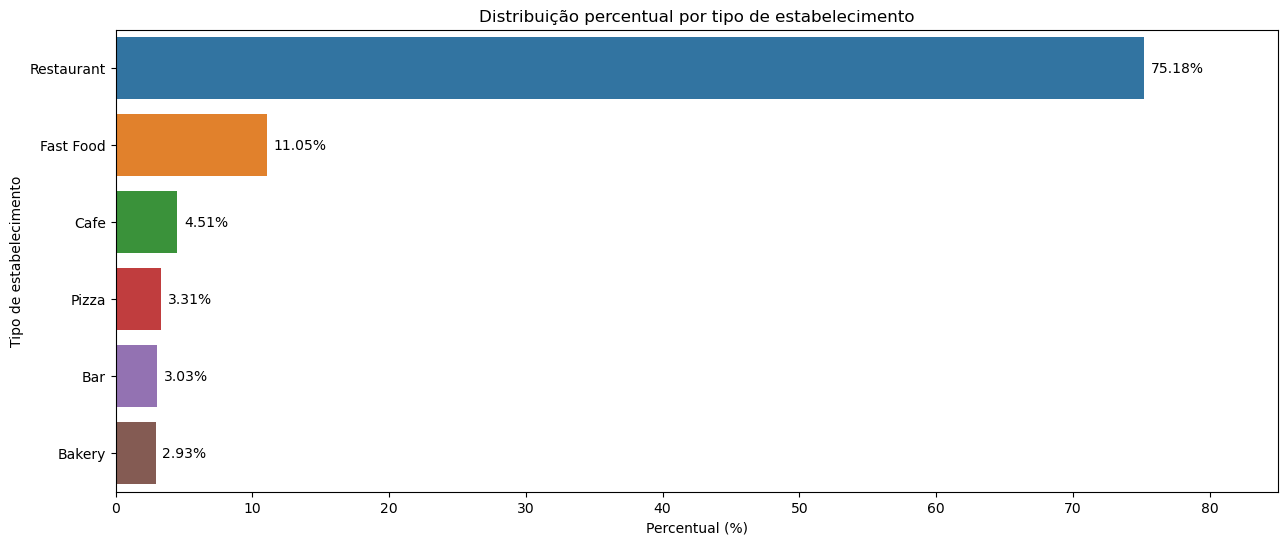

In [177]:
plt.figure(figsize=(15, 6))
ax = sns.barplot(data=type_unique,x='percentual',y='object_type')

plt.title('Distribuição percentual por tipo de estabelecimento')
plt.xlabel('Percentual (%)')
plt.ylabel('Tipo de estabelecimento')
plt.xlim(0, 85)

for i, v in enumerate(type_unique['percentual']):
    ax.text(v + 0.5, i, f'{v:.2f}%', va='center')

plt.show()


O gráfico evidencia que os restaurantes dominam amplamente as redes, representando cerca de 75% dos estabelecimentos.  
O fast food aparece como o segundo tipo mais comum, com pouco mais de 11%, enquanto cafés, pizzarias, bares e padarias possuem participação individual inferior a 5%.  
Isso indica que as redes concentram fortemente suas operações em formatos tradicionais de restaurante, com menor diversificação entre outros tipos de estabelecimento.

### 5.2 - Investigue as proporções de estabelecimentos de rede e não. Construa um gráfico.

In [178]:
network_comparison = data['chain'].value_counts()
network_comparison = (data['chain'].value_counts().reset_index().rename(columns={'index': 'chain', 'chain': 'quantidade'}))
network_total = network_comparison['quantidade'].sum()
network_comparison['percentual'] = (network_comparison['quantidade'] / network_total * 100).round(2)
network_comparison['chain'] = network_comparison['chain'].replace({True: 'Sim',False: 'Não'})

print(network_comparison)

  chain  quantidade  percentual
0   Não        5972        61.9
1   Sim        3676        38.1


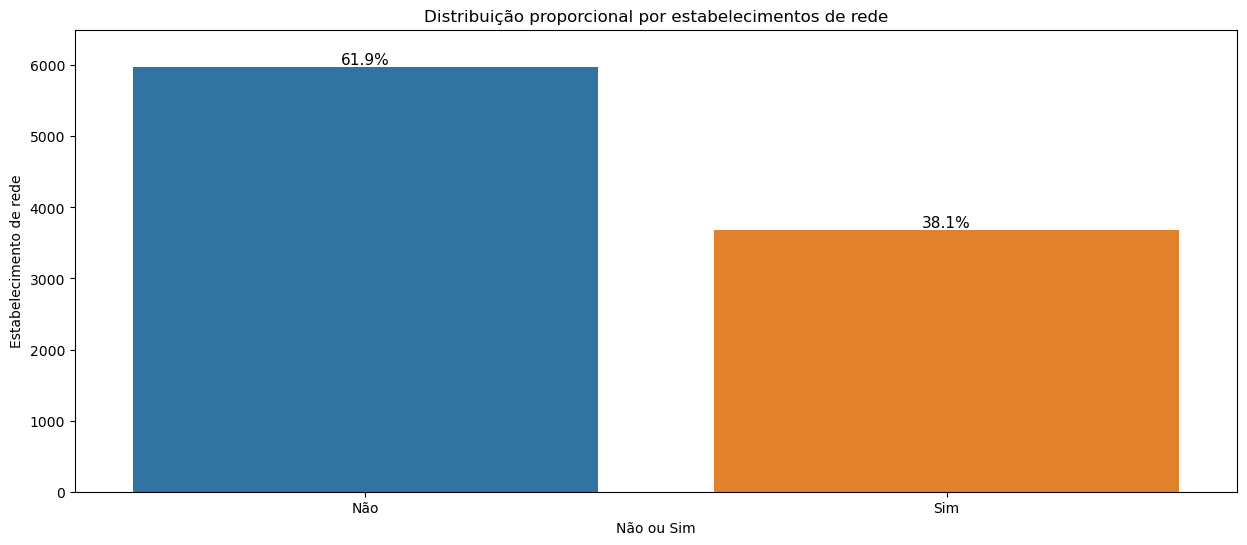

In [179]:
plt.figure(figsize=(15, 6))
ax = sns.barplot(data=network_comparison,y='quantidade',x='chain')

plt.title('Distribuição proporcional por estabelecimentos de rede')
plt.xlabel('Não ou Sim')
plt.ylabel('Estabelecimento de rede')
plt.ylim(0,6500)

for p, pct in zip(ax.patches, network_comparison['percentual']):ax.annotate(f'{pct:.1f}%',(p.get_x() + p.get_width() / 2, p.get_height()),ha='center',va='bottom',fontsize=11)

plt.show()

A partir do gráfico acima podemos notar que o numero de estabelecimentos de rede na cidade de Los Angeles é significativo com 38,1% de todos que possuem na cidade, quase metade se formos parar para analisar.

### 5.3 - Qual tipo de estabelecimento é típico para redes?

In [180]:
network_types = data[data['chain']== True]
network_types = network_types['object_type'].value_counts()
network_types = (network_types.reset_index().rename(columns={'index': 'object_type', 'object_type': 'quantidade'}))
network_types['percentual'] = ((network_types['quantidade'] / network_types['quantidade'].sum()) * 100).round(2)

network_types.head()

,object_type,quantidade,percentual
0,Restaurant,2292,62.35
1,Fast Food,605,16.46
2,Bakery,283,7.70
3,Cafe,266,7.24
4,Pizza,153,4.16


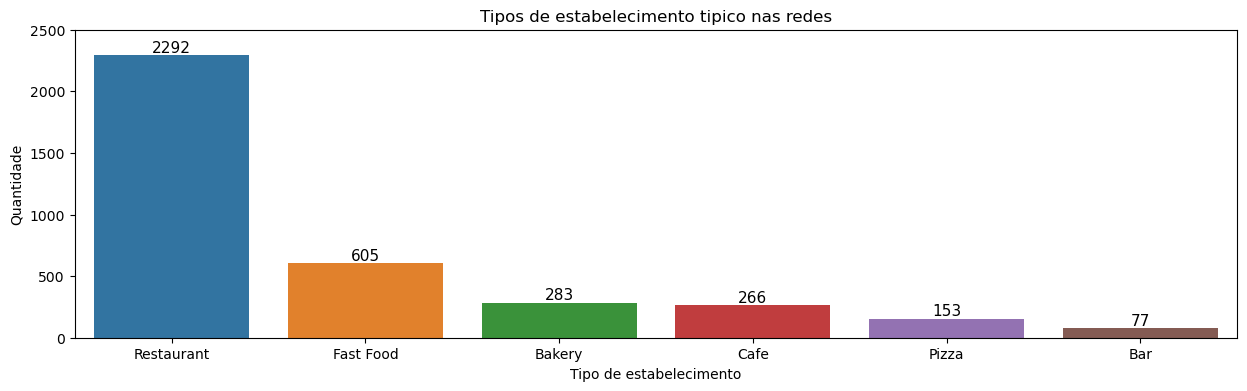

In [181]:
plt.figure(figsize=(15,4))
ax=sns.barplot(data=network_types,x='object_type',y='quantidade')

plt.title('Tipos de estabelecimento tipico nas redes')
plt.xlabel('Tipo de estabelecimento')
plt.ylabel('Quantidade')
plt.ylim(0,2500)

for p, valor in zip(ax.patches, network_types['quantidade']):ax.annotate(f'{valor}',(p.get_x() + p.get_width() / 2, p.get_height()),ha='center',va='bottom',fontsize=11)

plt.show()

O gráfico mostra que os restaurantes são, de longe, o tipo de estabelecimento mais comum entre as redes, seguidos por fast food.  
Tipos como bakery, café e pizza aparecem com menor frequência, enquanto bares são pouco representados.  
Esses resultados indicam que as redes concentram suas operações principalmente em formatos tradicionais de restaurante e fast food, que favorecem maior padronização e escala.

### 5.4 - O que caracteriza redes: muitos estabelecimentos com um pequeno número de assentos ou poucos estabelecimentos com muitos assentos?

In [182]:
network_yes = data[data['chain'] == True].copy()
network_yes['qtd_object'] = (network_yes.groupby('object_name')['object_name'].transform('count'))
network_yes[['object_name', 'qtd_object']].drop_duplicates().sample(10)
networks_df = (network_yes.groupby('object_name').agg(qtd_estabelecimentos=('qtd_object', 'first'),assentos_medio=('number', 'mean'),assentos_mediana=('number', 'median')).reset_index())

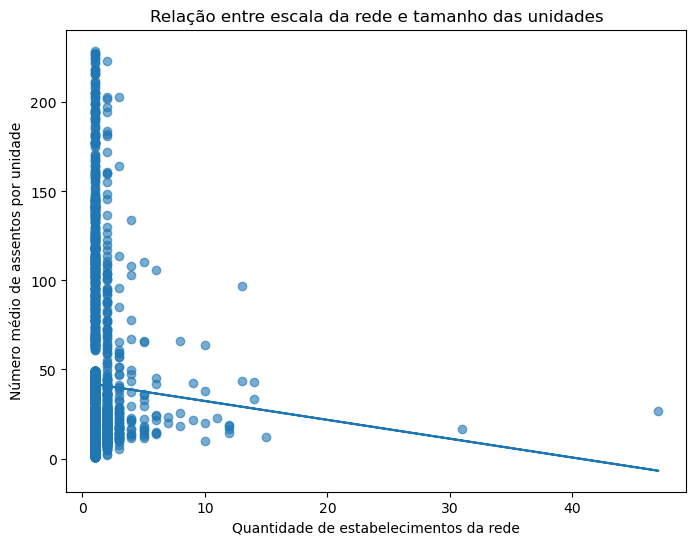

In [183]:
x = networks_df['qtd_estabelecimentos']
y = networks_df['assentos_medio']

coef = np.polyfit(x, y, 1)
trend = np.poly1d(coef)

plt.figure(figsize=(8,6))
plt.scatter(x, y, alpha=0.6)
plt.plot(x, trend(x))

plt.xlabel('Quantidade de estabelecimentos da rede')
plt.ylabel('Número médio de assentos por unidade')
plt.title('Relação entre escala da rede e tamanho das unidades')

plt.show()


Escala da rede vs tamanho das unidades

O gráfico de dispersão mostra que redes com poucas unidades apresentam grande variabilidade no número médio de assentos.  
No entanto, à medida que o número de estabelecimentos da rede aumenta, os valores tendem a se concentrar em unidades menores.  
A inclinação negativa da linha de tendência indica que as redes são caracterizadas principalmente por muitos estabelecimentos com poucos assentos, e não por poucos estabelecimentos de grande porte.

### 5.5 - Determine o número médio de assentos para cada tipo de restaurante. Em média, qual tipo de restaurante tem o maior número de assentos? Construa gráficos.

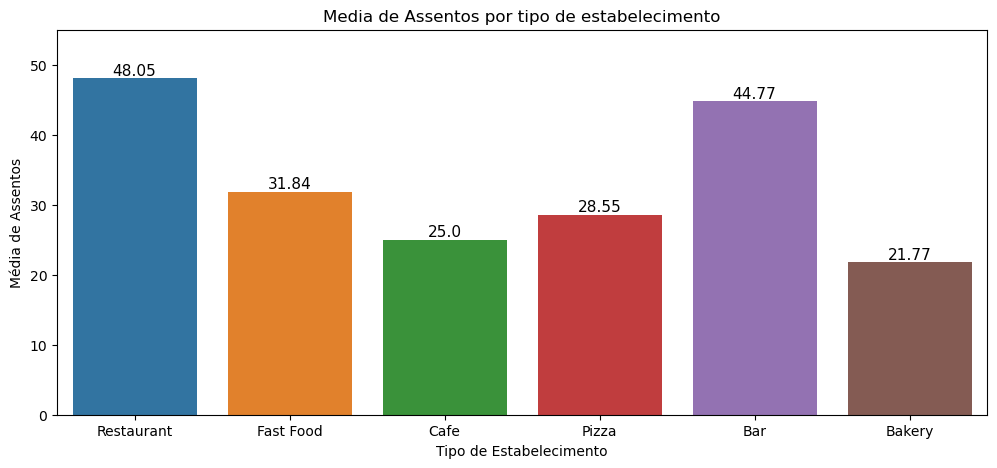

In [184]:
network_type_mean_seat = (data.groupby('object_type').agg(quantidade=('object_type','count'), assentos_total=('number','sum'), assentos_medio=('number','mean')).reset_index().sort_values(by='quantidade', ascending=False))
network_type_mean_seat['assentos_medio'] = network_type_mean_seat['assentos_medio'].round(2)

plt.figure(figsize=(12,5))
ax = sns.barplot(data=network_type_mean_seat,y='assentos_medio',x='object_type')
plt.xlabel('Tipo de Estabelecimento')
plt.ylabel('Média de Assentos')
plt.title('Media de Assentos por tipo de estabelecimento')
plt.ylim(0,55)



for p, valor in zip(ax.patches, network_type_mean_seat['assentos_medio']):ax.annotate(f'{valor}',(p.get_x() + p.get_width() / 2, p.get_height()),ha='center',va='bottom',fontsize=11)


plt.show()

O gráfico mostra que restaurantes e bares possuem as maiores médias de assentos, indicando estabelecimentos de maior porte.  
Em contraste, cafés e padarias apresentam as menores médias, caracterizando unidades mais compactas.  
Os tipos fast food e pizza ocupam uma posição intermediária, sugerindo formatos padronizados com tamanho moderado.

### 5.6 - Coloque os dados dos nomes das ruas da coluna address em uma coluna separada.

In [185]:
data = data.copy()
data['street_name'] = (data['address'].str.upper().str.replace(r'^\d+\s+[NSEW]\s+', '', regex=True)
    .str.replace(r'^\d+\s+', '', regex=True).str.replace(r'\s+(STE|UNIT|APT|SUITE|#).*$', '', regex=True).str.replace(r'\s+\d+$', '', regex=True).str.strip())

data.head()

,id,object_name,address,chain,object_type,number,street_name
0,11786,HABITAT COFFEE SHOP,3708 N EAGLE ROCK BLVD,False,Cafe,26,EAGLE ROCK BLVD
1,11787,REILLY'S,100 WORLD WAY 120,False,Restaurant,9,WORLD WAY
2,11788,STREET CHURROS,6801 HOLLYWOOD BLVD 253,False,Fast Food,20,HOLLYWOOD BLVD
3,11789,TRINITI ECHO PARK,1814 W SUNSET BLVD,False,Restaurant,22,SUNSET BLVD
4,11790,POLLEN,2100 ECHO PARK AVE,False,Restaurant,20,ECHO PARK AVE


### 5.7 - Construa um gráfico de dez ruas com o maior número de restaurantes.

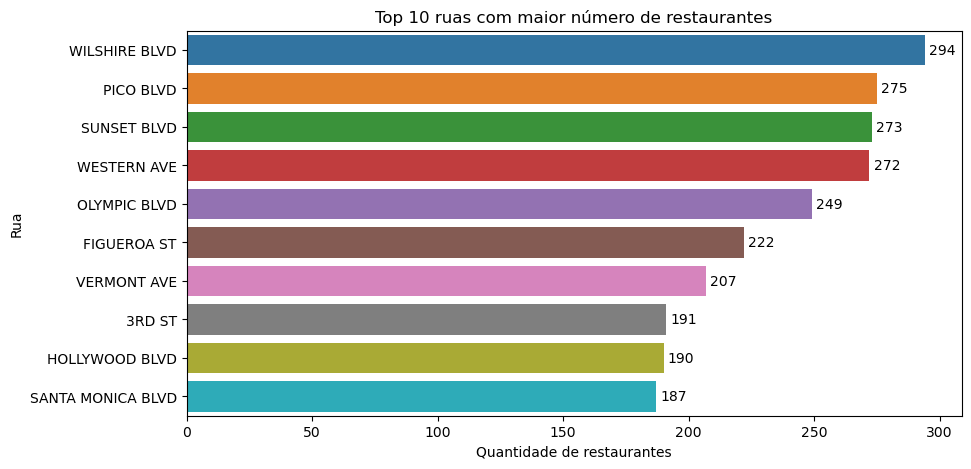

In [186]:
#Aplicando filtro para os 10 ruas com maiores numeros de restaurantes.
restaurants = data[data['object_type'] == 'Restaurant']
top10street = (restaurants['street_name'].value_counts().head(10).reset_index())
top10street.columns = ['street_name', 'quantidade']

plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=top10street,
    x='quantidade',
    y='street_name'
)

plt.xlabel('Quantidade de restaurantes')
plt.ylabel('Rua')
plt.title('Top 10 ruas com maior número de restaurantes')

# rótulos no topo das barras
for p in ax.patches:
    ax.annotate(
        int(p.get_width()),
        (p.get_width(), p.get_y() + p.get_height() / 2),
        va='center',
        ha='left',
        xytext=(3, 0),
        textcoords='offset points'
    )

plt.show()


O gráfico mostra que Wilshire Blvd, Pico Blvd e Sunset Blvd concentram o maior número de restaurantes, destacando-se como importantes corredores gastronômicos da cidade.  
As demais ruas do ranking também apresentam alta concentração de estabelecimentos, indicando que a atividade gastronômica em Los Angeles se organiza ao longo de grandes avenidas, que oferecem maior visibilidade, fluxo de pessoas e acessibilidade.

### 5.8 - Encontre o número de ruas que têm apenas um restaurante.

In [187]:
streets_one_restaurant = (data[data['object_type'] == 'Restaurant'].groupby('street_name').size().reset_index(name='quantidade'))
num_streets_one_restaurant = streets_one_restaurant[streets_one_restaurant['quantidade'] == 1].shape[0]

print('Existem',num_streets_one_restaurant,'ruas com somente 1 restaurante espalhadas pela cidade.')

Existem 594 ruas com somente 1 restaurante espalhadas pela cidade.


Foi identificado o número de ruas que possuem apenas um restaurante, indicando áreas com baixa concentração de estabelecimentos gastronômicos.  
Esse resultado contrasta com os corredores gastronômicos observados anteriormente, onde há grande concentração de restaurantes em poucas ruas.


### 5.9 - Para as ruas com muitos restaurantes, olhe para a distribuição de número de assentos. Quais tendências você consegue notar?

In [188]:
top_streets = top10street['street_name']
restaurants_top_streets = data[(data['object_type'] == 'Restaurant') &(data['street_name'].isin(top_streets))]

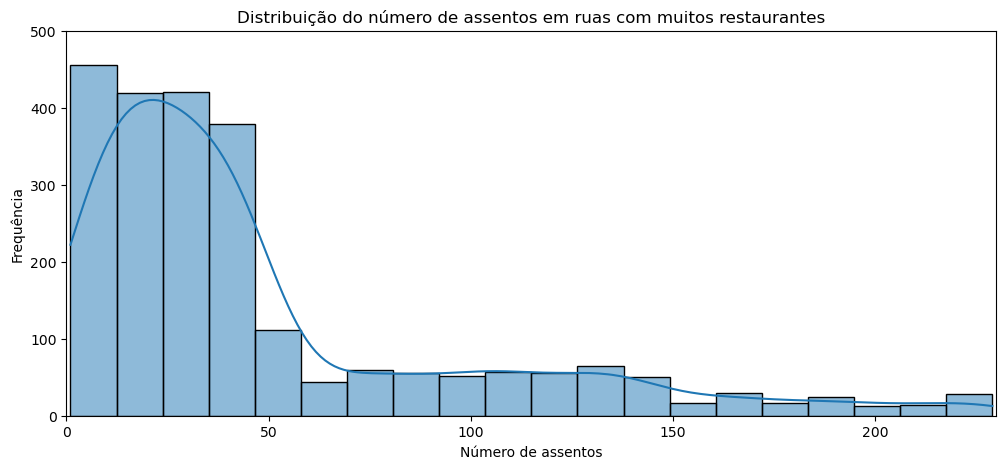

In [189]:
plt.figure(figsize=(12,5))
sns.histplot(restaurants_top_streets['number'], bins=20, kde=True)
plt.xlabel('Número de assentos')
plt.ylabel('Frequência')
plt.title('Distribuição do número de assentos em ruas com muitos restaurantes')
plt.xlim(0,230)
plt.ylim(0,500)
plt.show()


A distribuição apresenta forte concentração de restaurantes com baixo a médio número de assentos, principalmente até cerca de 50 lugares, além de uma cauda longa à direita, indicando poucos estabelecimentos de grande porte.  
Esse padrão sugere que ruas com muitos restaurantes tendem a concentrar diversos estabelecimentos menores, em vez de poucos restaurantes grandes, favorecendo maior densidade e diversidade gastronômica.

### 5.10 - Conclusão Geral

A partir da análise dos dados dos estabelecimentos de alimentação em Los Angeles, foi possível identificar padrões claros relacionados à estrutura do mercado gastronômico, à distribuição espacial dos restaurantes e às estratégias de escala adotadas pelos estabelecimentos.

Os resultados mostram que o setor é amplamente dominado por restaurantes tradicionais, que representam a maior parte dos estabelecimentos tanto em quantidade absoluta quanto em participação percentual. Outros tipos, como fast food, cafés, padarias, pizzarias e bares, aparecem em menor proporção, indicando que o formato de restaurante continua sendo o principal modelo operacional da cidade. No entanto, ao analisar a média de assentos por tipo, observa-se que restaurantes e bares tendem a ter maior capacidade, enquanto cafés e padarias operam majoritariamente em espaços menores, refletindo diferenças claras de perfil e proposta de consumo.

A análise espacial revelou uma forte concentração de restaurantes em grandes avenidas, como Wilshire Blvd, Pico Blvd e Sunset Blvd, que se destacam como verdadeiros corredores gastronômicos. Essas vias concentram centenas de estabelecimentos, enquanto uma grande quantidade de ruas possui apenas um único restaurante, evidenciando uma distribuição desigual e altamente centralizada da atividade gastronômica na cidade.

Ao investigar especificamente as ruas com maior número de restaurantes, observou-se que a alta densidade não está associada a restaurantes de grande porte, mas sim à presença de muitos estabelecimentos de pequeno e médio tamanho. A distribuição do número de assentos nessas ruas é assimétrica, com forte concentração em valores baixos e uma cauda longa à direita, indicando que poucos restaurantes muito grandes coexistem com uma maioria de unidades compactas. Esse padrão sugere que a estratégia dominante nesses corredores gastronômicos é baseada na multiplicidade de unidades, favorecendo diversidade, rotatividade e aproveitamento do espaço urbano.

De forma geral, o cenário gastronômico de Los Angeles pode ser caracterizado por alta concentração espacial, predominância de estabelecimentos menores, e modelos de escala baseados em quantidade e padronização, especialmente em áreas de grande fluxo. Esses resultados oferecem uma visão consistente da dinâmica urbana e comercial do setor, podendo servir como base para decisões estratégicas de expansão, estudos de mercado e análises sobre planejamento urbano e uso do espaço na cidade.

## 6 - Apresentação

Segue o link da Apresentação: <[link para um armazenamento em nuvem](https://drive.google.com/file/d/1BDJ3nhrFMPgE9_pG2l9axR-WH10JI64Q/view?usp=sharing)>